In [294]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
from sklearn.model_selection import KFold
from scipy.stats import t

phot_data = pd.read_csv("string_phot_rat_data.csv")
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered', 'rat'])
data = data.dropna()
# seperate data into testing and training dat
# find random indexes that account for around 25% of the data
test_ix = numpy.random.randint(0, data.shape[0],round(data.shape[0]/4))
test_data = data.iloc[test_ix].copy()
# get a list of the indicies to keep in the training data
train_ix = list(set(range(data.shape[0])) - set(test_ix))
train_data = data.iloc[train_ix].copy()

In [300]:
def linear_regression_gradient_descent(X, y):
    if len(X.shape) > 1:
        n_samples, n_features = X.shape
        weights = numpy.zeros(n_features)
    else:
        n_samples = X.size
        n_features = 1
        weights = 0
    # implement gradient descent
    # set initial weights and biases
    bias = 1
    learning_rate = 0.001
    epochs = 10000

    # fit the model
    for epoch in range(epochs):
        # calculate predicted y
        y_predicted = numpy.dot(X, weights) + bias
        # get the error for weights and bias
        diff_w = (1/n_samples) * numpy.dot(X.T, (y_predicted - y))
        diff_b = (1/n_samples) * numpy.sum(y_predicted - y)  

        # update weights and biases
        weights -= learning_rate*diff_w
        bias -= learning_rate*diff_b
    return weights, bias


def calculate_RSE(y_pred, y, n_sample, n_params):
    rss = numpy.sum((y_pred - y)**2)
    rse = numpy.sqrt(rss/(n_sample-n_params-1))
    return rse

def calculate_SE(x, rse):
    se = rse/numpy.sqrt(numpy.sum((x-numpy.mean(x))**2))
    return se

def calculate_R2(y, y_pred):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - (RSS/TSS)
    return R2

def calculate_adjusted_R2(y, y_pred, n, p):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - ((RSS/(n - p - 1))/(TSS/(n - 1)))
    return R2


def calculate_F(y, y_pred, n_features, n_samples):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    # compute the residual sum of squares
    RSS = numpy.sum(numpy.square(y-y_pred))
    F = ((TSS-RSS)/n_features)/((RSS)/(n_samples - n_features - 1))
    return F

def calculate_tstat(x, rse, B):
    se = calculate_SE(x, rse)
    tstat = B/se
    return tstat


def k_fold_cross_val(X, y, n_samples, n_params):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rses = []
    r2s = []
    for trainIX, testIX in kf.split(y):
        train_X, test_X = X[trainIX], X[testIX]
        train_y, test_y = y[trainIX], y[testIX]
        weight, bias = linear_regression_gradient_descent(train_X, train_y)
        y_pred = numpy.dot(test_X, weight) + bias
        rse = calculate_RSE(y_pred, test_y, len(test_y), n_params)
        rses.append(rse)
        adjusted_R2 = calculate_adjusted_R2(test_y, y_pred, len(test_y), n_params)
        r2s.append(adjusted_R2)
    rse =  numpy.mean(rses)
    adj_r2 = numpy.mean(r2s)
    return rse, adj_r2       

In [301]:
def simple_reg_for_each_parameter(X_df, y):    
    simple_reg_dict = {}
    for param in X_df.columns:
        X = X_df[param].to_numpy()
        rse, adj_r2 = k_fold_cross_val(X, y, X.size, 1)
        weight, bias = linear_regression_gradient_descent(X, y)
        simple_reg_dict[param] = [bias, weight, rse, adj_r2]
        plt.figure()
        plt.scatter(X_df[param], y)
        plt.axline(xy1=(0,bias), slope=weight)
        plt.xlabel(param)
    return simple_reg_dict

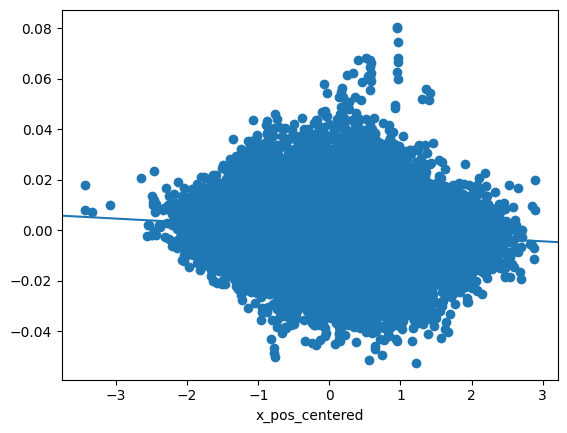

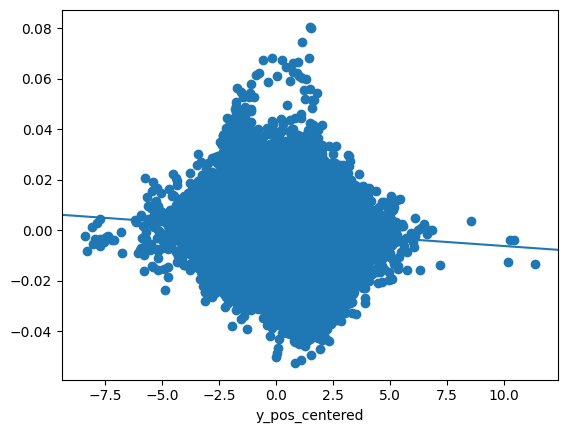

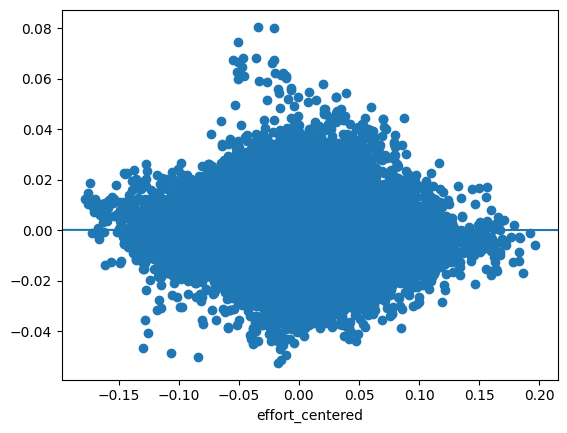

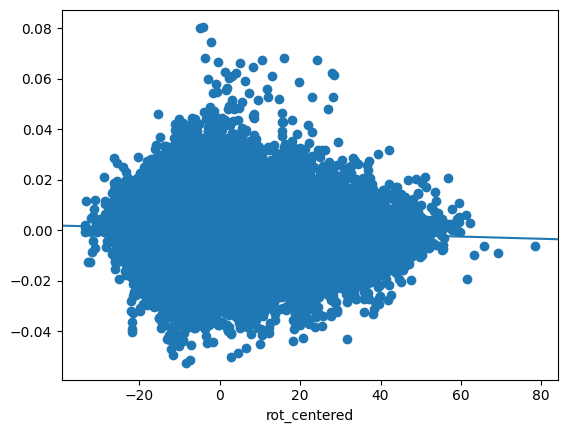

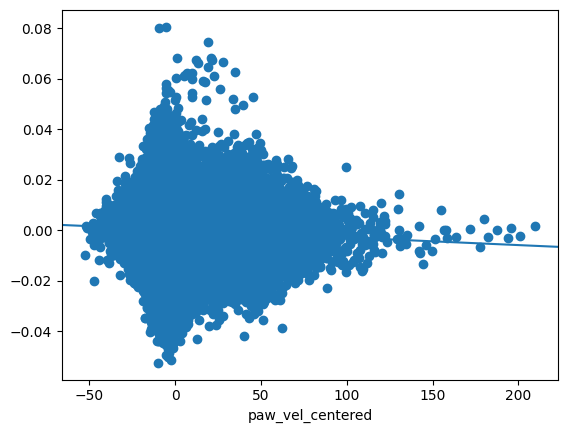

In [307]:
X_df = train_data.drop(columns=['df_centered'])
X = X_df.to_numpy()
y = train_data['df_centered'].to_numpy()

simple = simple_reg_for_each_parameter(X_df, y)

In [303]:
pd.DataFrame(simple, index=['bias', 'weight', 'rse', 'adj_r2']).head()

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
bias,0.000047,0.000047,0.000047,0.000047,0.000048
weight,-0.001509,-0.000636,-0.000113,-0.000045,-0.000030
rse,0.008623,0.008656,0.008704,0.008688,0.008684
adj_r2,0.018458,0.011104,-0.000068,0.003627,0.004507


In [310]:
def multiple_linreg(X, y):
    n_samples, n_features = X.shape
    rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
    weight, bias = linear_regression_gradient_descent(X, y)
    y_pred = numpy.dot(X, weight) + bias
    plt.figure()
    plt.scatter(y_pred, y-y_pred)
    return weight, bias, rse, adj_r2

In [309]:
rses = []
r2s = []
for param in X_df.drop(columns=['x_pos_centered']).columns:
        params = ['x_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
print(X_df.columns)
print(rses)
print(r2s)

Index(['x_pos_centered', 'y_pos_centered', 'effort_centered', 'rot_centered',
       'paw_vel_centered'],
      dtype='object')
[np.float64(0.008614976681642645), np.float64(0.008624749467192933), np.float64(0.008624793045621916), np.float64(0.00862473123724314)]
[np.float64(0.02042915123348079), np.float64(0.018208053159874216), np.float64(0.01819812694990024), np.float64(0.018211904563515135)]


In [311]:
rses = []
r2s = []
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
print(X_df.columns)
print(rses)
print(r2s)

Index(['x_pos_centered', 'y_pos_centered', 'effort_centered', 'rot_centered',
       'paw_vel_centered'],
      dtype='object')
[np.float64(0.008615133143731175), np.float64(0.008615112412901112), np.float64(0.00861544509145025)]
[np.float64(0.02039356527011773), np.float64(0.020398326247195973), np.float64(0.02032168022611891)]


In [312]:
rses = []
r2s =[]
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered', 'rot_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered', 'rot_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
print(X_df.columns)
print(rses)
print(r2s)

Index(['x_pos_centered', 'y_pos_centered', 'effort_centered', 'rot_centered',
       'paw_vel_centered'],
      dtype='object')
[np.float64(0.008615267516202979), np.float64(0.008615541680624672)]
[np.float64(0.020363045113594012), np.float64(0.020299877088246942)]


0.020266255568667502


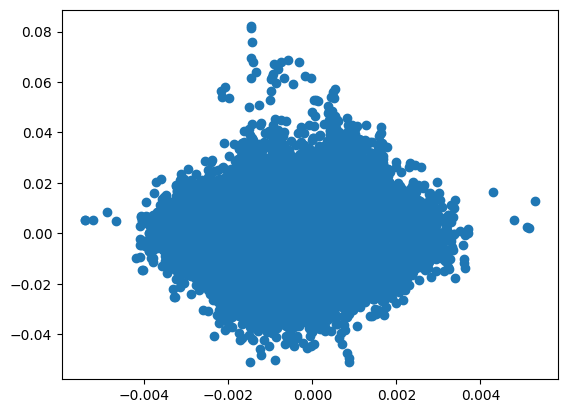

In [313]:
weight, bias, rse, r2 = multiple_linreg(X_df.to_numpy(), y)
print(r2)

In [314]:
print(rse, r2)

0.008615689466741875 0.020266255568667502


0.00890824435037281 -0.0474313559825418


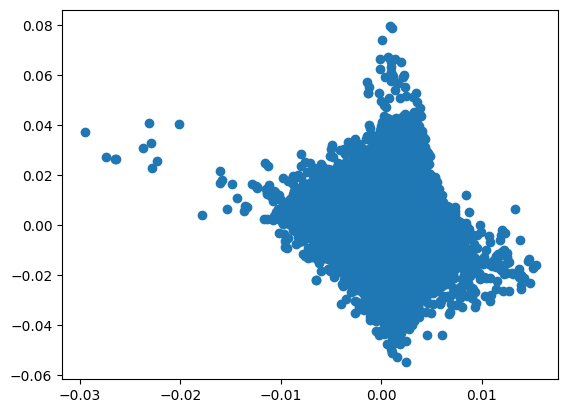

In [321]:
paw_df = X_df.copy()
paw_interaction = X_df['x_pos_centered'] * X_df['y_pos_centered']
paw_df['paw_interaction'] = paw_interaction
rse, adj_r2 = k_fold_cross_val(paw_df.to_numpy(), y, paw_df.shape[0], paw_df.shape[1])
weights, bias, rse, r2 = multiple_linreg(paw_df.to_numpy(), y)
print(rse, adj_r2)

In [319]:
paw_df.shape[0]

103911

In [ ]:
interaction_df = X_df.copy()
paw_interaction = X_df['x_pos_centered'] * X_df['y_pos_centered']
interaction_df['paw_interaction'] = paw_interaction
string_interaction = X_df['x_pos_centered'] * X_df['paw_vel_centered']
interaction_df['string_interaction'] = string_interaction
weights, bias, rse, r2 = multiple_linreg(interaction_df.to_numpy(), y)
rse, adj_r2 = k_fold_cross_val(interaction_df.to_numpy(), y, interaction_df.shape[0], interaction_df.shape[1])
print(rse, adj_r2)